In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('creators_collected.csv')

In [63]:
df.head()

,handleName,followerCnt,currentScore,currentTier,scoreLowerLimit,scoreUpperLimit,displayType,avgSixSecondsViewsBenchMarkViews,avgSixSecondsViewsRate,avgSixSecondsViewsRateRank,...,median_view_recent,var_view_recent,mean_view_recent,std_view_recent,cov_view_recent,mean_iet_days_recent,std_iet_days_recent,burstiness_recent,total_span_days_recent,recency_days_recent
0,ongthibalong,1063460,70.0,1.0,0.0,100.0,1,0.4604,0.4215,0.6008,...,56334.0,2.088164e+11,1.934880e+05,4.569643e+05,2.361719,1.068552,0.534533,-0.333119,14.959734,3.469942
1,maitrithuc2020,2024865,70.0,1.0,0.0,100.0,1,0.4604,0.4896,0.4250,...,510016.0,1.842786e+12,1.152157e+06,1.357493e+06,1.178219,0.289000,0.324327,0.057600,4.045995,1.400810
2,utthuyss,1287643,NaN,0.0,NaN,NaN,1,0.4604,0.2525,0.8480,...,207247.0,2.950492e+10,2.726299e+05,1.717700e+05,0.630048,0.096873,0.163173,0.254958,1.356215,1.383530
3,nguyen_huynh_tien,3124254,70.0,1.0,0.0,100.0,1,0.4604,0.3096,0.7786,...,38135.0,4.258721e+09,6.821891e+04,6.525888e+04,0.956610,0.235975,0.326395,0.160784,2.359745,1.449954
4,khuyenduong299,1671668,70.0,1.0,0.0,100.0,1,0.4607,0.2484,0.8526,...,552760.0,2.187491e+12,1.321180e+06,1.479017e+06,1.119467,1.432848,1.408185,-0.008681,20.059873,3.432419


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9918 entries, 0 to 9917
Columns: 170 entries, handleName to recency_days_recent
dtypes: float64(166), int64(2), object(2)
memory usage: 12.9+ MB


In [ ]:
# bỏ các cột có quá nhiều giá trị thiếu (hơn 50%)
df = df.loc[:, df.isna().mean() < 0.5]

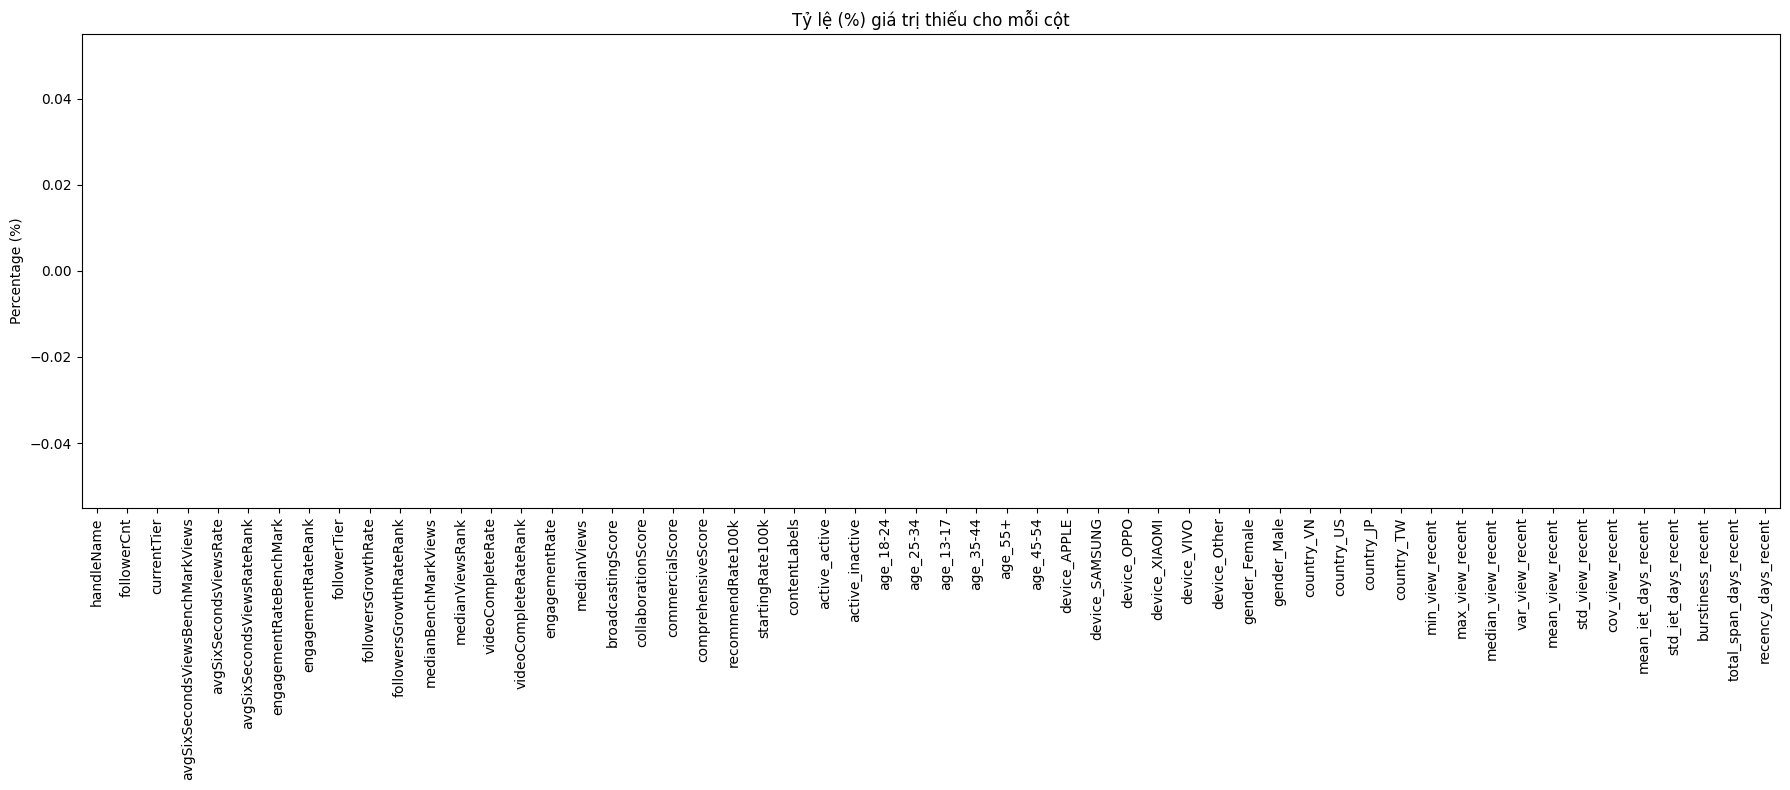

In [73]:
a = df.isna().mean() * 100  

plt.figure(figsize=(18, 8))
a.plot(kind='bar')

plt.title('Tỷ lệ (%) giá trị thiếu cho mỗi cột')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [67]:
df.columns

Index(['handleName', 'followerCnt', 'currentScore', 'currentTier',
       'scoreLowerLimit', 'scoreUpperLimit', 'displayType',
       'avgSixSecondsViewsBenchMarkViews', 'avgSixSecondsViewsRate',
       'avgSixSecondsViewsRateRank', 'engagementRateBenchMark',
       'engagementRateRank', 'followerTier', 'followersGrowthRate',
       'followersGrowthRateRank', 'medianBenchMarkViews', 'medianViewsRank',
       'videoCompleteRate', 'videoCompleteRateRank', 'engagementRate',
       'medianViews', 'broadcastingScore', 'collaborationScore',
       'commercialScore', 'comprehensiveScore', 'recommendRate100k',
       'startingRate100k', 'contentLabels', 'active_active', 'active_inactive',
       'age_18-24', 'age_25-34', 'age_13-17', 'age_35-44', 'age_55+',
       'age_45-54', 'device_APPLE', 'device_SAMSUNG', 'device_OPPO',
       'device_XIAOMI', 'device_VIVO', 'device_Other', 'gender_Female',
       'gender_Male', 'country_VN', 'country_US', 'country_JP', 'country_TW',
       'min_view_rece

In [68]:
df['currentScore'].value_counts()

currentScore
70.0     5744
100.0     344
57.0      206
0.0       194
65.0      146
         ... 
69.0        1
38.0        1
11.0        1
21.0        1
26.0        1
Name: count, Length: 87, dtype: int64

In [69]:
# Bỏ các cột không có giá trị
df.drop(columns=[ 'currentScore','scoreLowerLimit', 'scoreUpperLimit', 'displayType', ], inplace=True)

In [70]:
# creator không thiết lập nội dung cho kênh của họ, nên mình sẽ điền 'Unknown' vào các giá trị thiếu
df['contentLabels'] = df['contentLabels'].fillna('Unknown')

In [71]:
# Điền giá trị thiếu bằng mean của cột
df['active_active'] = df['active_active'].fillna(df['active_active'].mean()   )
df['active_inactive'] = df['active_inactive'].fillna(df['active_inactive'].mean())

In [72]:
# các cột có Na có nghĩa là không có chỉ số ở mục đó, nên mình sẽ điền 0 vào các giá trị thiếu
df = df.fillna(0)

In [74]:
df.to_csv('creators_processed.csv', index=False)